In [223]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier

import os


filename = "Reto_2_AFM.ipynb"  # Current file name
print(f"Current file name: {filename}\n")
print(f"Current absolute path: {os.getcwd()}\n")

# Specify the paths, relative to the current file
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output_data")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

# The HISTORICO_SUERTES.xlsx should be in the data directory
df_base = pd.read_excel(os.path.join(DATA_DIR, "BD_IPSA_1940.xlsx"))

# First, lets modify the column names
df_base.columns = [
    x.lower()
    .strip()
    .replace(" ", "_")
    .replace(".", "_")
    .replace("-", "_")
    .replace("(", "")
    .replace(")", "")
    .replace("%", "pct_")
    for x in df_base.columns
]

df_base.head(5)




Current file name: Reto_2_AFM.ipynb

Current absolute path: c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\repo\ML1_sugar_industry\notebooks

BASE_DIR: c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\repo\ML1_sugar_industry
DATA_DIR: c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\repo\ML1_sugar_industry\data
OUTPUT_DIR: c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\repo\ML1_sugar_industry\data\output_data


,unnamed:_0,nome,faz,tal,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,tch,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


In [247]:
# Cargar el dataset
df = df_base.copy()#pd.read_excel("/data/BD_IPSA_1940.xlsx")
df.shape

(2187, 21)

In [ ]:

# Selección de columnas relevantes
columns_to_keep = ["dosismad","semsmad", "edad", "cortes", "sacarosa", "tch", "lluvias",  "pct_diatrea"]
#"grupo_tenencia" 
df = df[columns_to_keep]

# Análisis de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
dosismad       0
semsmad        0
edad           0
cortes         0
sacarosa       0
tch            0
lluvias        0
pct_diatrea    0
dtype: int64


In [226]:

# Rellenar valores nulos con la media de cada columna
#df.fillna(df.mean(), inplace=True)

# Eliminar valores outliers en la columna 'semsmad'
df = df[(df['semsmad'] >= 5) & (df['semsmad'] <= 14.84)] #Mayor a Percentil 5 y menor a percentil 95
df = df[(df['tch'] <= 182) & (df['tch'] >= 40)] # Percentil 95
df = df[(df['cortes'] <= 8)] #  En Colombia, muchas plantaciones comerciales suelen resembrarse tras 5 a 7 cortes, dependiendo del rendimiento y costos de producción.En cultivos de alto rendimiento y suelos bien manejados: Puede alcanzar hasta 10 cortes en algunos casos.
df = df[(df['dosismad'] > 0) & (df['dosismad'] <= 2)]



In [227]:
df.shape

(1869, 8)

In [228]:
# Crear variables categóricas para TCH y Sacarosa
df['tch_category'] = pd.cut(df['tch'], bins=[-float('inf'), 100, 155, float('inf')], labels=['bajo', 'normal', 'alto'])
df['sacarosa_category'] = pd.cut(df['sacarosa'], bins=[-float('inf'), 11.5, 14.5, float('inf')], labels=['bajo', 'normal', 'alto'])


<Figure size 1200x600 with 0 Axes>

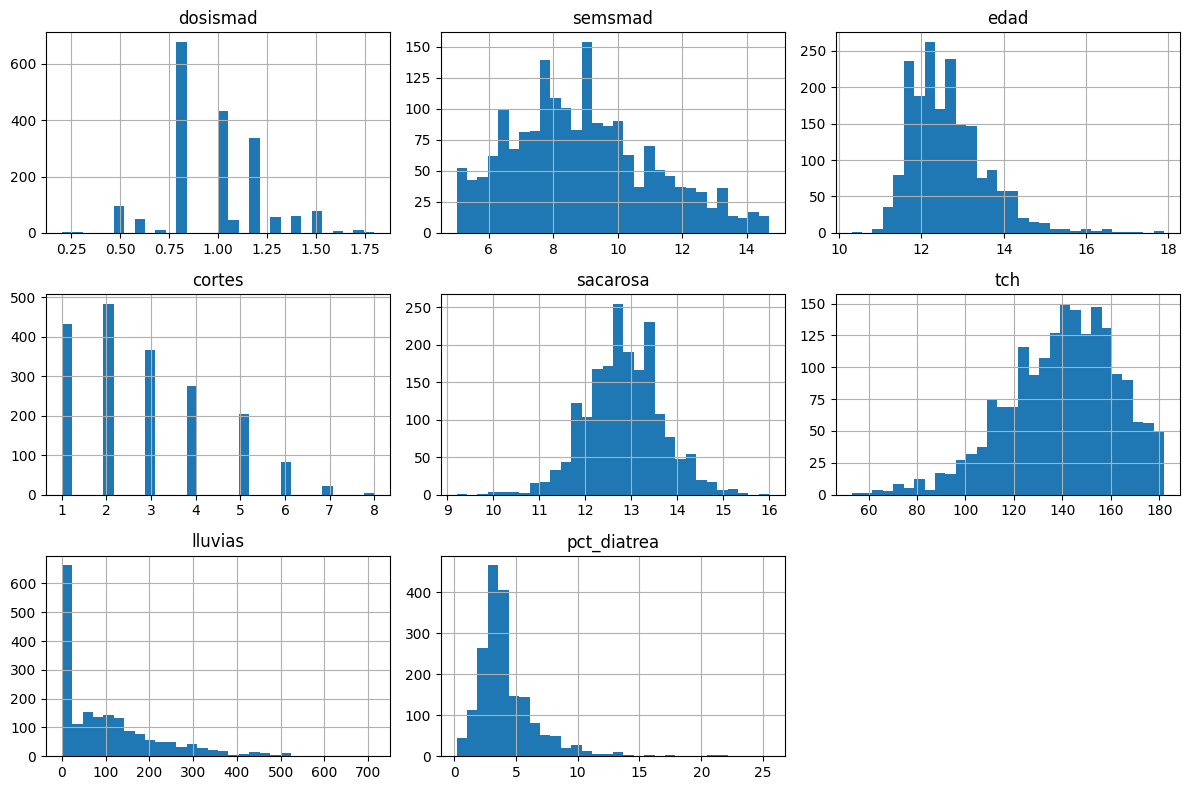

In [229]:
# Análisis de la distribución de variables
plt.figure(figsize=(12, 6))
df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()



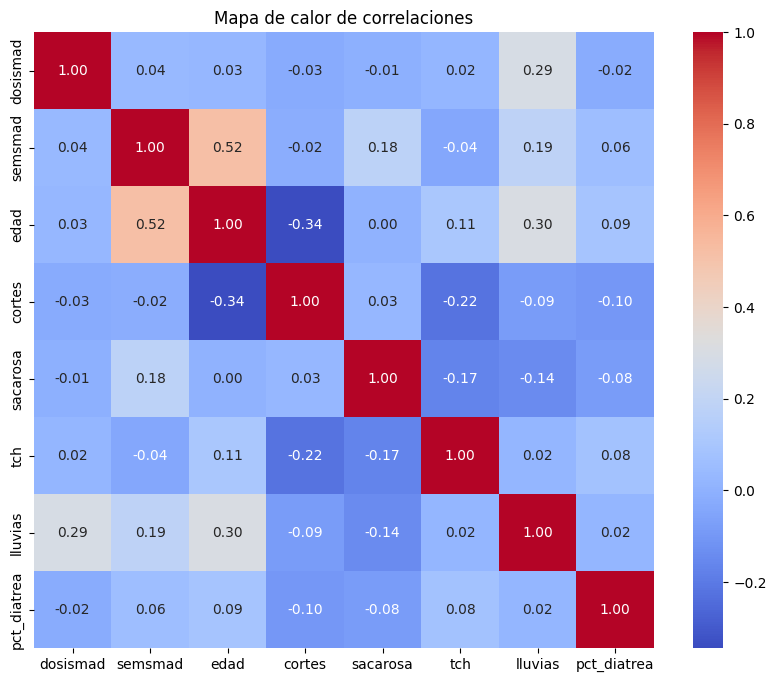

In [230]:
# Análisis de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df[columns_to_keep].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()



In [231]:
# Análisis de percentiles para TCH y Sacarosa
percentiles = [0, 5,10, 25, 50, 75, 90, 95,100]
percentile_values = df[['sacarosa', 'tch']].quantile([p/100 for p in percentiles])
print("Percentiles para TCH y Sacarosa:")
print(percentile_values)

Percentiles para TCH y Sacarosa:
      sacarosa    tch
0.00       9.2   53.0
0.05      11.5   99.4
0.10      11.8  110.0
0.25      12.3  126.0
0.50      12.8  142.0
0.75      13.4  157.0
0.90      13.9  168.0
0.95      14.2  174.0
1.00      16.0  182.0


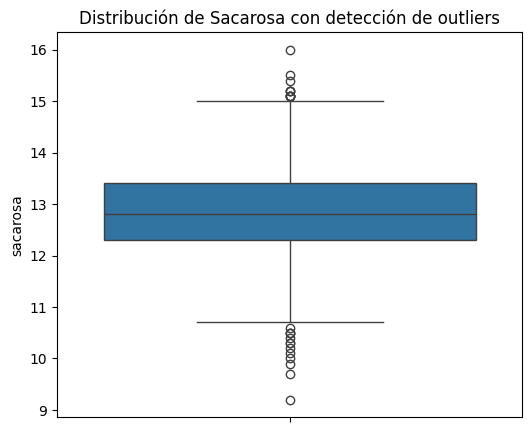

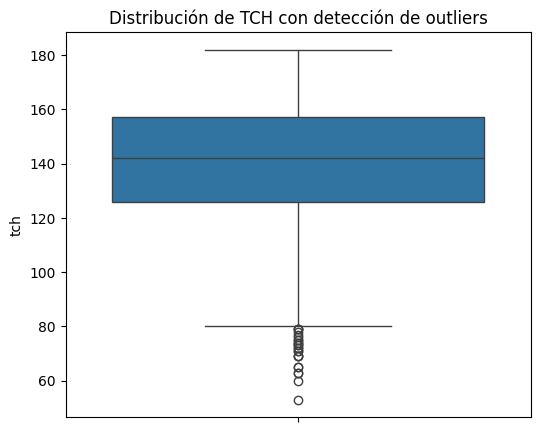

In [232]:
# Gráficos de las variables dependientes en gráficos separados
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['sacarosa'])
plt.title("Distribución de Sacarosa con detección de outliers")
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(y=df['tch'])
plt.title("Distribución de TCH con detección de outliers")
plt.show()

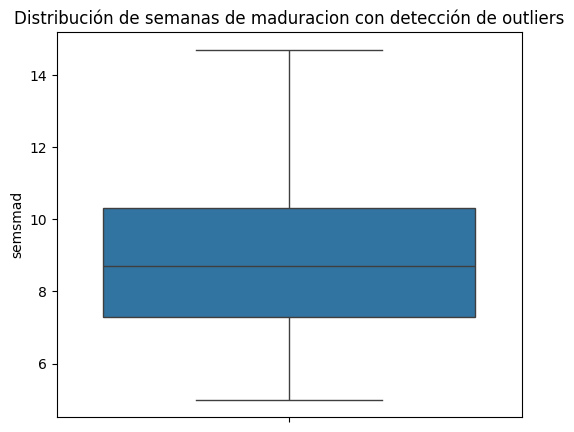

Percentiles para semsmad:
      semsmad
0.00      5.0
0.05      5.6
0.10      6.1
0.25      7.3
0.50      8.7
0.75     10.3
0.90     12.1
0.95     13.0
1.00     14.7


In [233]:
# Gráficos de las variables dependientes en gráficos separados
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['semsmad'])
plt.title("Distribución de semanas de maduracion con detección de outliers")
plt.show()

percentiles = [0, 5,10, 25, 50, 75, 90,95, 100]
percentile_values = df[['semsmad']].quantile([p/100 for p in percentiles])
print("Percentiles para semsmad:")
print(percentile_values)

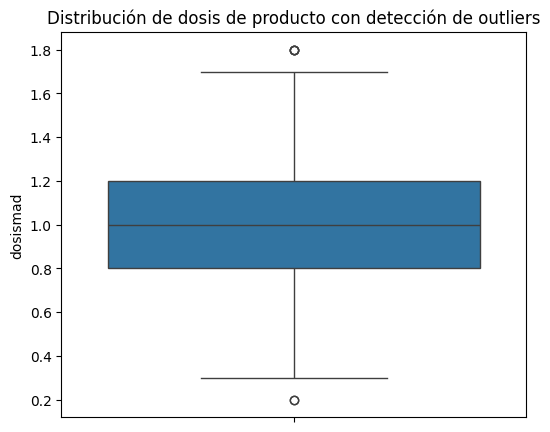

Percentiles para dosismad:
      dosismad
0.00       0.2
0.05       0.5
0.10       0.8
0.25       0.8
0.50       1.0
0.75       1.2
0.90       1.3
0.95       1.5
1.00       1.8


In [234]:
# Gráficos de las variables dependientes en gráficos separados
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['dosismad'])
plt.title("Distribución de dosis de producto con detección de outliers")
plt.show()

percentiles = [0, 5,10, 25, 50, 75, 90,95, 100]
percentile_values = df[['dosismad']].quantile([p/100 for p in percentiles])
print("Percentiles para dosismad:")
print(percentile_values)

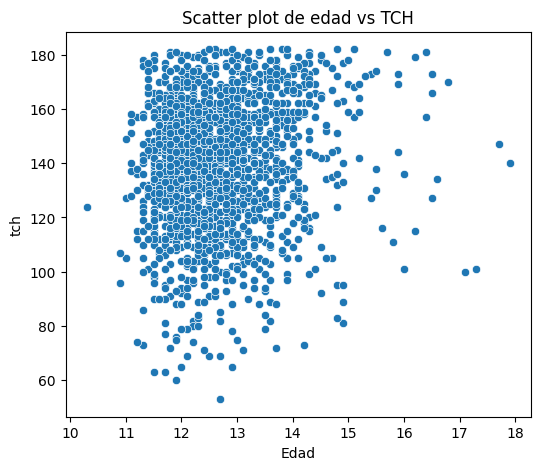

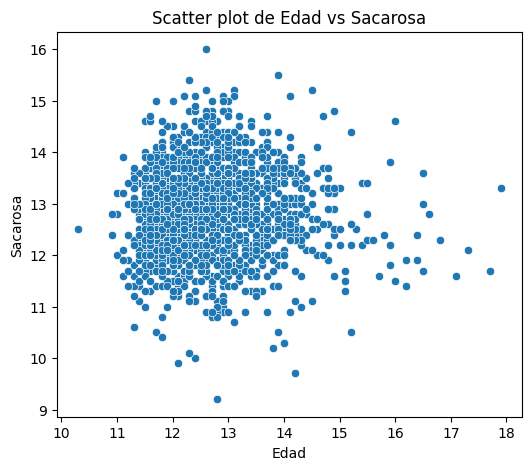

In [235]:
# Scatter plots de vejez vs TCH y Sacarosa
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['edad'], y=df['tch'])
plt.xlabel("Edad")
plt.ylabel("tch")
plt.title("Scatter plot de edad vs TCH")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['edad'], y=df['sacarosa'])
plt.xlabel("Edad")
plt.ylabel("Sacarosa")
plt.title("Scatter plot de Edad vs Sacarosa")
plt.show()

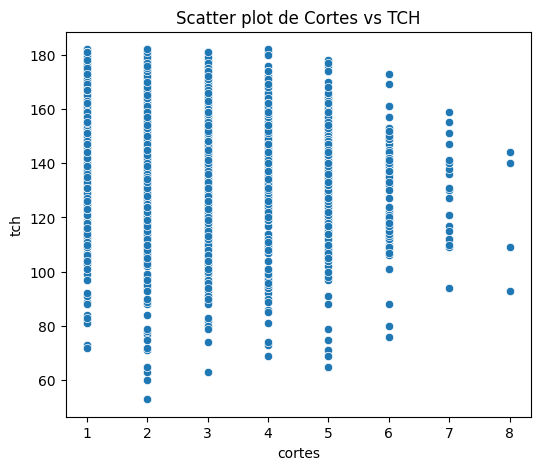

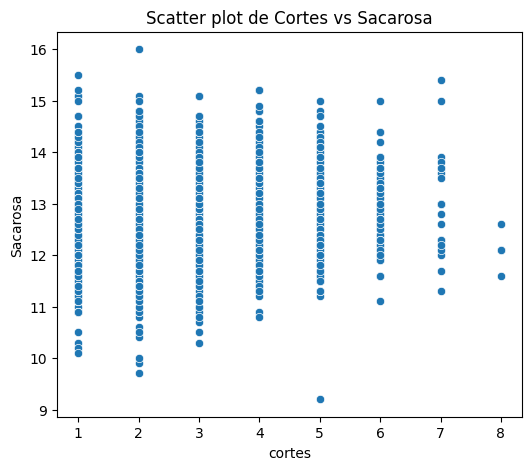

In [236]:
# Scatter plots de vejez vs TCH y Sacarosa
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['cortes'], y=df['tch'])
plt.xlabel("cortes")
plt.ylabel("tch")
plt.title("Scatter plot de Cortes vs TCH")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['cortes'], y=df['sacarosa'])
plt.xlabel("cortes")
plt.ylabel("Sacarosa")
plt.title("Scatter plot de Cortes vs Sacarosa")
plt.show()

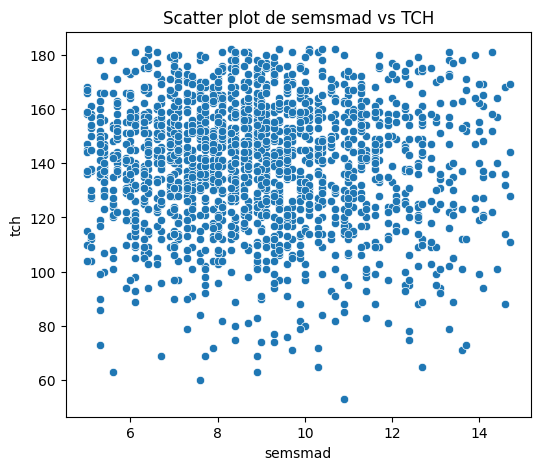

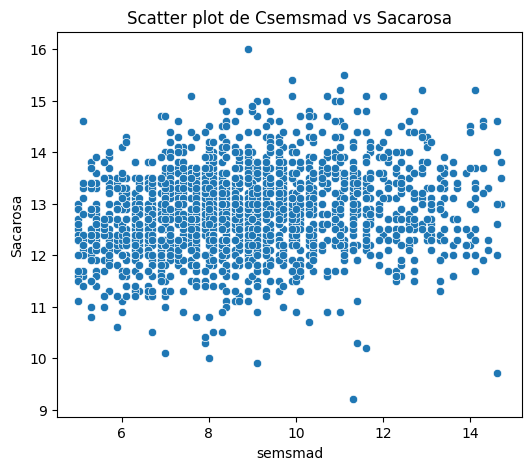

In [237]:
# Scatter plots de vejez vs TCH y Sacarosa
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['semsmad'], y=df['tch'])
plt.xlabel("semsmad")
plt.ylabel("tch")
plt.title("Scatter plot de semsmad vs TCH")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['semsmad'], y=df['sacarosa'])
plt.xlabel("semsmad")
plt.ylabel("Sacarosa")
plt.title("Scatter plot de Csemsmad vs Sacarosa")
plt.show()

In [238]:
# Detección de outliers usando el método IQR
for col in ['sacarosa', 'tch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Número de outliers en {col}: {len(outliers)}")

Número de outliers en sacarosa: 24
Número de outliers en tch: 25


In [239]:
# Variables dependientes y predictoras
X = df.drop(columns=["sacarosa", "tch", "sacarosa_category", "tch_category"])
y_sacarosa = df["sacarosa_category"]
y_TCH = df["tch_category"]



In [240]:
# División de datos para ambos modelos
X_train, X_test, y_train_sacarosa, y_test_sacarosa = train_test_split(X, y_sacarosa, test_size=0.2, random_state=42, stratify=y_sacarosa)

# Normalización de datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Validación cruzada K-Fold con k=10 y regularización Lasso
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#lasso_logreg = LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr')
lasso_logreg = OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear'))
cross_val_scores = cross_val_score(lasso_logreg, X_train, y_train_sacarosa, cv=skf, scoring='accuracy')
print(f"Resultados de validación cruzada (10-fold) - Regresión Logística Lasso: {cross_val_scores.mean():.4f}")




Resultados de validación cruzada (10-fold) - Regresión Logística Lasso: 0.9231


In [244]:
X_train, X_test, y_train_TCH, y_test_TCH = train_test_split(X, y_TCH, test_size=0.2, random_state=42, stratify=y_TCH)

# Normalización de datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Validación cruzada K-Fold con k=10 y regularización Lasso
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#lasso_logreg = LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr')
#lasso_logreg = OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear'))
cross_val_scores = cross_val_score(lasso_logreg, X_train, y_train_TCH, cv=skf, scoring='accuracy')
print(f"Resultados de validación cruzada (10-fold) - Regresión Logística Lasso: {cross_val_scores.mean():.4f}")



Resultados de validación cruzada (10-fold) - Regresión Logística Lasso: 0.6836


Resultados de validación cruzada (10-fold) - Regresión Logística Lasso: 0.9231


c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was

In [245]:
# Entrenar modelo con regularización Lasso
lasso_logreg.fit(X_train, y_train_sacarosa)
print("Coeficientes después de la regularización Lasso:")
print(lasso_logreg.coef_)


Coeficientes después de la regularización Lasso:


AttributeError: 'OneVsRestClassifier' object has no attribute 'coef_'

In [246]:
# Modelo de Regresión Logística
logreg = LogisticRegression(multi_class='ovr')
logreg.fit(X_train, y_train_sacarosa)
y_pred_sacarosa = logreg.predict(X_test)
print("Resultados para Regresión Logística - Sacarosa:")
print(classification_report(y_test_sacarosa, y_pred_sacarosa))

# Modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train_TCH)
y_pred_TCH = knn.predict(X_test)
print("Resultados para KNN - TCH:")
print(classification_report(y_test_TCH, y_pred_TCH))

Resultados para Regresión Logística - Sacarosa:
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00         9
        bajo       0.00      0.00      0.00        20
      normal       0.92      1.00      0.96       345

    accuracy                           0.92       374
   macro avg       0.31      0.33      0.32       374
weighted avg       0.85      0.92      0.89       374

Resultados para KNN - TCH:
              precision    recall  f1-score   support

        alto       0.56      0.43      0.49       100
        bajo       0.00      0.00      0.00        19
      normal       0.74      0.85      0.79       255

    accuracy                           0.69       374
   macro avg       0.43      0.43      0.43       374
weighted avg       0.66      0.69      0.67       374



c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\a7854\Documents\Maestria en Inteligencia Artificial Aplicada\Semestre 1\Aprendizaje Automatico I\Taller Practico\Lib\site-packages\sklearn\metrics\_classification.py:1565: Undefine